# Convolutional Neural Networks on CIFAR-10

In the last coding assignment you implemented a fully-connected neural network for image classification on
CIFAR-10 and achieved a test-set accuracy of around **~50 %**. This week you will improve
on that by switching to a **Convolutional Neural Network (CNN)** architecture that allows for a classification accuracy of **~83%**.

The notebook is split into two parts:

1. **Part 1 — Guided exercises (Tasks 1–4):** four independent functions that cover the
   core CNN building blocks. Each task has its own self-tests so you can verify your
   solution before moving on.
2. **Part 2 — Training & Evaluation:** a modern PyTorch training pipeline with
   TensorBoard logging, training-curve visualisation, and a quantitative / qualitative
   model analysis on the CIFAR-10 test set.

We strongly recommend watching the lecture and reviewing the slides before starting.

---

## Grading

Each task asks you to implement one Python function.
**Do not rename any function**, the autograder uses exact name matching.

| Task | Function | Points |
|:-----|:---------|:------:|
| 1 | [`conv2d_naive`](#task-1) | 10 |
| 2 | [`maxpool2d`](#task-2) | 10 |
| 3 | [`batch_norm_forward`](#task-3) | 10 |
| 4 | [`features_to_probs`](#task-4) | 10 |
| | **Total** | **40** |

---

## Dataset: CIFAR-10

As a short reminder: CIFAR-10 consists of **50 000 training** and **10 000 test** images, each a 32×32 RGB
photograph labelled with one of ten classes. We further split the training images into
45 000 training and 5 000 validation samples. The ten classes are:

![CIFAR-10 classes](https://pytorch.org/tutorials/_images/cifar10.png)


## GPU Usage

When training Convolutional Neural Networks (CNNs), a **Graphics Processing Unit (GPU)** offers significantly faster processing capabilities compared to a Central Processing Unit (CPU). This acceleration is crucial for handling the large computational demands of deep learning models. Google Colab provides free access to GPUs, which can dramatically reduce training times.

<span style="color:red">**IMPORTANT: To utilize a GPU, ensure your Colab runtime is set to GPU.** You can verify this by navigating to `Runtime > Change runtime type` and selecting 'GPU' under the 'Hardware accelerator' dropdown. This check should be performed at the very beginning, before running any cells.</span>

In [9]:
# NOTE: Execute this cell once before running any other code.
# It will install the necessary libraries and download the data.

!pip install numpy matplotlib torch torchvision tensorboard

# Download additonal utility files and data
import os

if not os.path.exists("data"):
    !git clone https://github.com/hpi-mlia-2026/coding_assignment_03.git
    %cd coding_assignment_03

Cloning into 'coding_assignment_03'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 12 (delta 4), reused 10 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 3.57 MiB | 21.53 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/coding_assignment_03/coding_assignment_03


In [10]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

from utils import (
    CIFAR10_CLASS_NAMES,
    compute_confusion_matrix,
    evaluate_model,
    get_cifar10_loaders,
    get_device,
    plot_prediction_gallery,
    plot_worst_images,
    predict_dataset,
    seed_everything,
    show_image_grid,
    train_model,
)

print("Imports successful.")
device = get_device()
print(f"Device: {device}")
if 'cpu' in str(device).lower():
    print("\nWARNING: You are running on CPU. For faster training, please switch to GPU runtime (Runtime > Change runtime type > GPU).")
else:
    print("\nGood! You are using a GPU for faster training.")

Imports successful.
Device: cuda

Good! You are using a GPU for faster training.


---

# Part 1 — Core CNN Building Blocks

## Background: From Fully-Connected to Convolutional Networks

Fully-connected (FC) networks treat every pixel as an independent input feature, so a
32×32×3 image already has **3 072 weights per neuron** in the first layer, and a 200×200×3
image would need **120 000**. This does not scale, and — more importantly — FC layers ignore
the *spatial structure* of images: nearby pixels are not treated differently from distant ones.

**Convolutional Neural Networks** (CNNs) fix both problems. Instead of connecting every
neuron to every input, a CNN applies a small learnable **filter** (e.g. 3×3) that slides
across the image, producing a 2D *activation map*. Because the same filter weights are
shared across all spatial positions (**weight sharing**), the number of parameters stays small
even for large images. In addition, the network learns filters that respond to specific
visual patterns — edges, blobs, textures at lower layers, and object parts at higher layers.

### CNN layer types

| Layer | Role |
|:------|:-----|
| **Conv** | Slide a filter over the input; compute dot products |
| **Activation (ReLU)** | Non-linearity; clamp negatives to zero |
| **BatchNorm** | Normalise activations per channel; stabilises training |
| **Pool (MaxPool)** | Downsample spatially; retain the strongest activation |
| **Fully-Connected** | Flatten feature maps; produce class scores |

The architecture in this assignment looks like:

```
INPUT [3×32×32]
  → CONV 64 filters → BN → ReLU → CONV 64 → BN → ReLU → MaxPool → Dropout
  → CONV 128 → BN → ReLU → CONV 128 → BN → ReLU → MaxPool → Dropout
  → CONV 256 → BN → ReLU → MaxPool → Dropout
  → Flatten → Linear(4096→512) → ReLU → Dropout → Linear(512→10) → Softmax
```

![CNN overview](https://i.imgur.com/1agcV6t.png)

---

## The Convolutional Layer in Detail

The CONV layer consists of a set of learnable **filters**. Each filter is small spatially
(e.g. 3×3) but extends through the full *depth* of the input (i.e. all channels). During the
forward pass the filter slides across height and width, and at each position it computes the
element-wise product with the covered patch and sums the result.

### Hyperparameters

**Filter size** (`k`) - height and width of a square filter.

**Stride** (`s`) — step size between successive filter positions.

**Zero-padding** (`p`) — zeros appended around the border.

The new height $H_{\text{out}}$ of the CONV layer output is given by
$$H_{\text{out}} = \left\lfloor \frac{H + 2p - k}{s} \right\rfloor + 1$$

Using `p = (k-1)/2` with `s = 1`
preserves the spatial dimensions (also called "same padding"). NumPy's `np.pad` is your friend here.

**Number of filters** — determines the depth (number of channels) of the output volume.

![Stride demo](https://i.imgur.com/CRTziQV.png)
![Padding demo](https://i.imgur.com/ZyLyf7P.png)


---

## Task 1: `conv2d_naive` — 2D Convolution
<a id="task-1"></a>

Implement a **naive 2D convolution** for a single-channel (grayscale) image. The goal is to implement the convolution by yourself without using any ready-to-use functions from libraries.

This function takes a single-channel image (`x`) and a convolution kernel (`w`) as input. It also takes `stride` to define the step size for the kernel and `pad` to specify the amount of zero-padding around the image borders. The function will produce a new 2D array, which is the result of applying the convolution kernel to the input image.


In [19]:
def conv2d_naive(x: np.ndarray, w: np.ndarray, stride: int = 1, pad: int = 0) -> np.ndarray:
    """Naive 2D convolution for a single-channel image.

    Parameters
    ----------
    x : np.ndarray, shape (H, W)
        Input image.
    w : np.ndarray, shape (kH, kW)
        Convolution kernel.
    stride : int
        Sliding step.
    pad : int
        Zero padding applied on all sides.
    """

    import numpy as np

def conv2d_naive(x, w, stride=1, pad=0):
    x_padded = np.pad(x, pad, mode='constant', constant_values=0)
    H, W = x.shape
    kH, kW = w.shape
    out_H = (H + 2*pad - kH) // stride + 1
    out_W = (W + 2*pad - kW) // stride + 1
    out = np.zeros((out_H, out_W))
    for i in range(out_H):
        for j in range(out_W):
            patch = x_padded[i*stride : i*stride+kH,
                             j*stride : j*stride+kW]
            out[i,j] = np.sum(patch * w)
    return out

In [20]:
# ── Task 1 Self-Test ──────────────────────────────────────────
print("Running Task 1 self-tests...")

x = np.arange(16, dtype=np.float32).reshape(4, 4)
w = np.array([[1.0, 2.0], [3.0, 4.0]], dtype=np.float32)

# Basic output values
out = conv2d_naive(x, w)
expected = np.array([[34, 44, 54], [74, 84, 94], [114, 124, 134]], dtype=np.float32)
assert out.shape == (3, 3) and np.allclose(out, expected), \
    f"Output incorrect.\nGot:\n{out}\nExpected:\n{expected}"

# Stride subsamples the output
assert conv2d_naive(x, w, stride=2).shape == (2, 2), \
    "With stride=2 the output should be (2, 2) for this input and kernel."

# Same-padding preserves spatial size
out_p = conv2d_naive(np.ones((8, 8), dtype=np.float32), np.ones((3, 3), dtype=np.float32) / 9, pad=1)
assert out_p.shape == (8, 8), \
    "pad=1 with a 3×3 kernel should preserve the spatial dimensions of the input."

print("Task 1 tests passed!")


Running Task 1 self-tests...
Task 1 tests passed!


### Visualization: Your `conv2d_naive` in Action

Convolutions are not magic — they are just sliding dot products. The cells below
apply your implementation to a synthetic image using three hand-crafted filters:

| Filter | Shape | What it detects |
|:-------|:------|:----------------|
| Sobel X | 3×3 | Vertical edges (gradient in x-direction) |
| Sobel Y | 3×3 | Horizontal edges (gradient in y-direction) |
| Box blur | 5×5 | Local average — smooths noise |

The **edge magnitude** `sqrt(edge_x² + edge_y²)` detects boundaries regardless of
orientation. The filters your CNN *learns* (Tasks 3-4 area) are optimised versions of
these hand-crafted ones, tuned to the CIFAR-10 classification task.


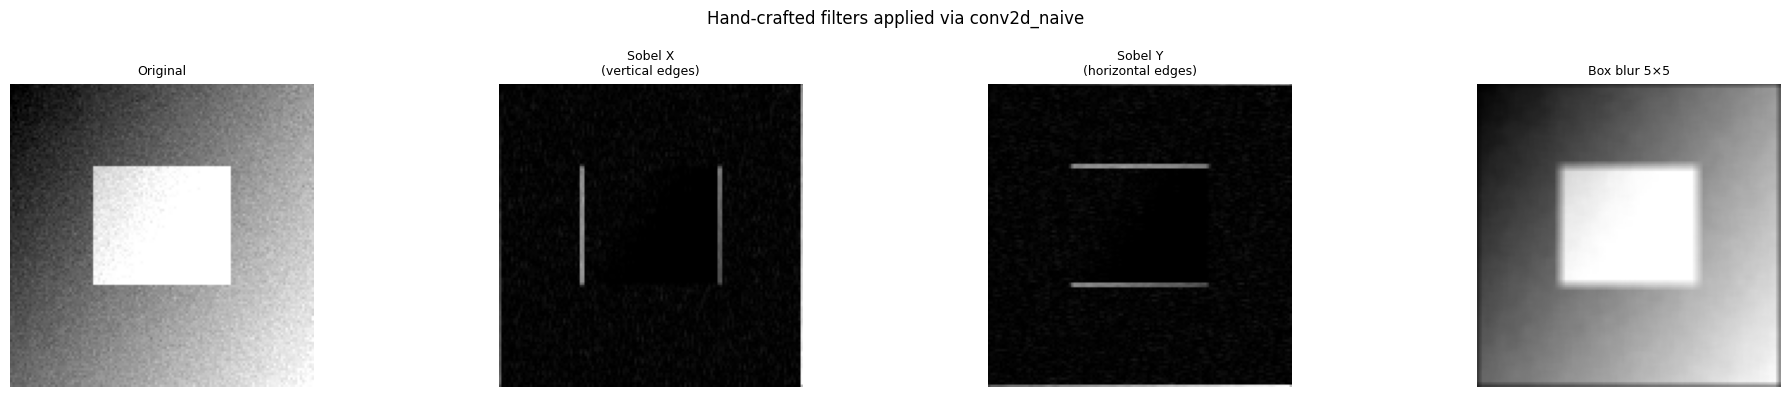

In [18]:
# Synthetic test image — self-contained, no download needed
rng_demo = np.random.default_rng(42)
H_d, W_d = 128, 128

demo_img = np.zeros((H_d, W_d), dtype=np.float32)
demo_img += np.linspace(0.0, 0.6, W_d, dtype=np.float32)
demo_img += np.linspace(0.0, 0.4, H_d, dtype=np.float32).reshape(-1, 1)
demo_img[35:85, 35:93] += 0.55                               # bright rectangle
demo_img += rng_demo.normal(0, 0.03, (H_d, W_d)).astype(np.float32)
demo_img = np.clip(demo_img, 0.0, 1.0)

# Hand-crafted filters
sobel_x = np.array([[-1,  0,  1], [-2, 0, 2], [-1,  0,  1]], dtype=np.float32)
sobel_y = np.array([[-1, -2, -1], [ 0, 0, 0], [ 1,  2,  1]], dtype=np.float32)
box5    = np.ones((5, 5), dtype=np.float32) / 25.0

# Apply using your implementation (same-padding → output matches input size)
edge_x  = conv2d_naive(demo_img, sobel_x, stride=1, pad=1)
edge_y  = conv2d_naive(demo_img, sobel_y, stride=1, pad=1)
blurred = conv2d_naive(demo_img, box5,    stride=1, pad=2)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, img, title in zip(
    axes,
    [demo_img, np.abs(edge_x), np.abs(edge_y), blurred],
    ["Original", "Sobel X\n(vertical edges)", "Sobel Y\n(horizontal edges)", "Box blur 5×5"],
):
    ax.imshow(img, cmap="gray", vmin=0, vmax=max(img.max(), 1e-6))
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.suptitle("Hand-crafted filters applied via conv2d_naive", fontsize=12)
plt.tight_layout()
plt.show()


![correct_comparison](https://github.com/hpi-mlia-2026/coding_assignment_03/blob/main/correct_filter_comparison.png?raw=1)

---

## Task 2: `maxpool2d` — Max Pooling
<a id="task-2"></a>

### Background: Pooling Layers

After a convolutional + ReLU block we **downsample** the feature map with a
**max-pooling** layer. A 2×2 max-pool with stride 2 halves both height and width
(reducing the resolution by 4×), while keeping the channel depth unchanged.

For each non-overlapping 2×2 region the layer passes the **maximum** activation:

$$p_{(i,j)} = \max\left(a_{(2i,2j)},\, a_{(2i,2j+1)},\, a_{(2i+1,2j)},\, a_{(2i+1,2j+1)}\right)$$

This makes the representation slightly **translation-invariant**: a feature detected
one pixel to the left or right produces the same pooled output.

![Max Pooling](https://i.imgur.com/ccxu58n.png)

### Your task

Implement a **naive 2D max pooling** for a single-channel image. This function takes a single-channel image (`x`), a `pool_size` for the pooling window, and a `stride` to define the step size. The function will produce a new 2D array, which is the result of applying max pooling to the input image.

In [21]:
def maxpool2d(x: np.ndarray, pool_size: int = 2, stride: int = 2) -> np.ndarray:
    """Naive max pooling for a single-channel image."""

    H, W = x.shape
    out_H = (H - pool_size) // stride + 1
    out_W = (W - pool_size) // stride + 1
    out = np.zeros((out_H, out_W), dtype=np.float32)

    for i in range(out_H):
        for j in range(out_W):

            region = x[
                i*stride : i*stride + pool_size,
                j*stride : j*stride + pool_size
            ]
            out[i, j] = np.max(region)
    return out


In [22]:
# ── Task 2 Self-Test ──────────────────────────────────────────
print("Running Task 2 self-tests...")

x = np.array([[1,2,3,4],[5,6,7,8],[9,10,11,12],[13,14,15,16]], dtype=np.float32)
out = maxpool2d(x, pool_size=2, stride=2)
expected = np.array([[6.0, 8.0], [14.0, 16.0]], dtype=np.float32)
assert out.shape == (2, 2) and np.allclose(out, expected), \
    f"Output incorrect.\nGot:\n{out}\nExpected:\n{expected}"

# The operation must select the maximum, not the mean or sum
x2 = np.array([[5.0, 1.0], [1.0, 1.0]], dtype=np.float32)
assert maxpool2d(x2)[0, 0] == 5.0, \
    "maxpool2d should return the largest value in the window, not the average."

print("Task 2 tests passed!")


Running Task 2 self-tests...
Task 2 tests passed!


### Visualization: Your `maxpool2d` in Action

Max pooling *compresses* the spatial resolution of a feature map while keeping the
dominant activations. The figure below shows:

- **Left**: a 64×64 synthetic feature map with four "detected features" (bright blobs).
- **Middle**: the same map after a 2×2 pool (stride 2) — resolution halved to 32×32.
- **Right**: after a 4×4 pool (stride 4) — resolution quartered to 16×16.

Notice that the blob positions are preserved even at lower resolution — this is the
**spatial invariance** effect of pooling that makes CNNs robust to small translations.


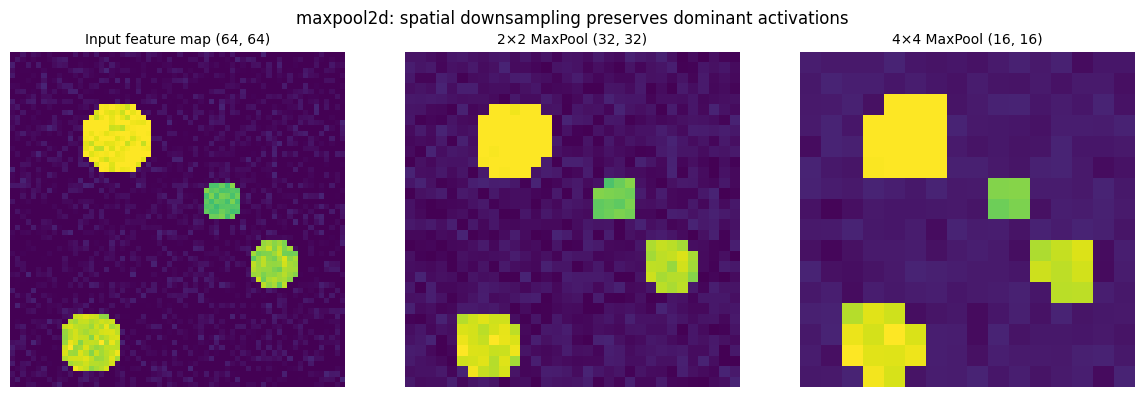

In [23]:
rng_pool = np.random.default_rng(123)
feat = np.zeros((64, 64), dtype=np.float32)
for (cy, cx, r, v) in [(16, 20, 7, 1.0), (40, 50, 5, 0.85), (55, 15, 6, 0.9), (28, 40, 4, 0.75)]:
    yy, xx = np.ogrid[:64, :64]
    feat[(yy - cy) ** 2 + (xx - cx) ** 2 < r ** 2] = v
feat += rng_pool.normal(0, 0.04, (64, 64)).astype(np.float32).clip(-0.1, 0.1)
feat = feat.clip(0, 1)

pooled2 = maxpool2d(feat, pool_size=2, stride=2)   # → 32×32
pooled4 = maxpool2d(feat, pool_size=4, stride=4)   # → 16×16

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(
    axes,
    [feat, pooled2, pooled4],
    [f"Input feature map {feat.shape}", f"2×2 MaxPool {pooled2.shape}", f"4×4 MaxPool {pooled4.shape}"],
):
    ax.imshow(img, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.suptitle("maxpool2d: spatial downsampling preserves dominant activations", fontsize=12)
plt.tight_layout()
plt.show()


![Correct maxpool comparison](https://github.com/hpi-mlia-2026/coding_assignment_03/blob/main/correct_maxpool_comparison.png?raw=1)

---

## Task 3: `batch_norm_forward` — Batch Normalization
<a id="task-3"></a>

### Background: Why Batch Normalization?

Training deep networks is hard: activations can explode or vanish as they pass through
many layers. **Batch Normalization (BN)** solves this by normalising each feature to
zero mean and unit variance *within each mini-batch*, then applying a learned affine
rescaling. In practice it:

- Allows **higher learning rates** and makes training much more stable.
- Acts as a mild **regularizer** (the added batch noise slightly dampens overfitting).
- Reduces sensitivity to weight initialisation.

In the `SmallCIFAR10CNN` model a `nn.BatchNorm2d` layer appears right after every
`nn.Conv2d`, normalising each feature channel across the batch and spatial positions.

### Your task

Implement the training-time forward pass for a batch of **B single-channel feature maps** of size W × H.
This function takes a mini-batch of single-channel feature maps (`x` of shape `(B, W, H)`), a learnable scale (`gamma`) and shift (`beta`), both of shape `(W, H)`, and returns the batch-normalised output of the same shape `(B, W, H)`.


In [ ]:
def batch_norm_forward(
    x: np.ndarray,
    gamma: np.ndarray,
    beta: np.ndarray,
    eps: float = 1e-5,
) -> np.ndarray:
    """Training-time forward pass of Batch Normalization for a batch of 2D feature maps.

    Parameters
    ----------
    x : np.ndarray, shape (B, W, H)
        Mini-batch of B single-channel feature maps, each of size W x H.
    gamma : np.ndarray, shape (W, H)
        Learnable scale parameter.
    beta : np.ndarray, shape (W, H)
        Learnable shift parameter.
    eps : float
        Small constant for numerical stability.

    Returns
    -------
    out : np.ndarray, shape (B, W, H)
        Batch-normalised and affine-transformed output.
    """

    out = None

    return out


In [ ]:
# ── Task 3 Self-Test ──────────────────────────────────────────
print("Running Task 3 self-tests...")

rng = np.random.default_rng(42)
x   = rng.normal(5.0, 3.0, (50, 8, 8)).astype(np.float32)
out = batch_norm_forward(x,
                         gamma=np.ones((8, 8), dtype=np.float32),
                         beta=np.zeros((8, 8), dtype=np.float32))

assert out.shape == x.shape, \
    f"Output shape {out.shape} should match input shape {x.shape}."

assert np.allclose(out.mean(axis=0), 0, atol=1e-4), \
    "With gamma=1 and beta=0, the batch mean at each spatial position should be ~0."

assert np.allclose(out.std(axis=0), 1.0, atol=1e-3), \
    "With gamma=1 and beta=0, the batch std at each spatial position should be ~1."

print("Task 3 tests passed!")


---

## Task 4: `features_to_probs` — Classification Head with Softmax
<a id="task-4"></a>

### Background: From Feature Maps to Class Probabilities

Your task is to implement a simple classification head that is applied after the last pooling layer.

This function takes the 3D feature maps output from the last pooling layer (`x`), a weight matrix (`W`), and a bias vector (`b`). It flattens the feature maps, applies a linear transformation to obtain raw scores (logits), and then converts these logits into class probabilities using the softmax operation. The final output is a 1D array representing the probability for each class.


In [ ]:
def features_to_probs(x: np.ndarray, W: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Flatten feature maps, apply a linear layer, and convert to class probabilities.

    Parameters
    ----------
    x : np.ndarray, shape (C, H, W)
        Feature maps from the last pooling layer.
    W : np.ndarray, shape (C * H * W, num_classes)
        Weight matrix.
    b : np.ndarray, shape (num_classes,)
        Bias vector.

    Returns
    -------
    probs : np.ndarray, shape (num_classes,)
        Class probabilities; non-negative and summing to 1.
    """

    probs = None

    return probs


In [ ]:
# ── Task 4 Self-Test ──────────────────────────────────────────
print("Running Task 4 self-tests...")

rng   = np.random.default_rng(5)
x     = rng.random((4, 4, 4)).astype(np.float32)
W     = rng.random((64, 10)).astype(np.float32)
b     = rng.random(10).astype(np.float32)
probs = features_to_probs(x, W, b)

assert probs.shape == (10,), \
    f"Output shape should be (10,), got {probs.shape}."

assert np.isclose(probs.sum(), 1.0, atol=1e-6), \
    f"Probabilities should sum to 1.0, got {probs.sum():.6f}."

assert probs.min() >= 0.0, \
    "All probabilities must be non-negative."

print("Task 4 tests passed!")


---

# Part 2 — Model Training

## The `SmallCIFAR10CNN` Architecture

The model below uses modern best-practices:

| Technique | Purpose |
|:----------|:--------|
| **Batch Normalization** | Stabilises training (same concept as Task 3) |
| **Dropout** | Regularisation; reduces co-adaptation of neurons |
| **Three conv blocks** | Each block doubles channels; MaxPool halves spatial size |

The final classifier mirrors Task 4 conceptually: the `(256, 4, 4)` feature volume is
flattened and fed through two fully-connected layers, producing logits for 10 classes.
PyTorch's `CrossEntropyLoss` internally applies softmax (as in Task 4) during training.

```
Input (3, 32, 32)
  Block 1: Conv(3→64)×2 + BN + ReLU + MaxPool  → (64, 16, 16)
  Block 2: Conv(64→128)×2 + BN + ReLU + MaxPool → (128, 8, 8)
  Block 3: Conv(128→256) + BN + ReLU + MaxPool  → (256, 4, 4)
  Classifier: Flatten → Linear(4096→512) → ReLU → Dropout → Linear(512→10)
```


In [ ]:
class SmallCIFAR10CNN(nn.Module):
    def __init__(self, num_classes: int = 10) -> None:
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),          # 32 → 16
            nn.Dropout(0.10),
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),          # 16 → 8
            nn.Dropout(0.15),
            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),          # 8 → 4
            nn.Dropout(0.20),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.50),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x


# Quick sanity check
_dummy = torch.zeros(1, 3, 32, 32)
_out   = SmallCIFAR10CNN()(_dummy)
assert _out.shape == (1, 10), f"Unexpected output shape: {_out.shape}"
total_params = sum(p.numel() for p in SmallCIFAR10CNN().parameters())
print(f"SmallCIFAR10CNN defined. Number of parameters: {total_params:,}")


## Training Setup

The `train_model` utility in `utils.py` provides a complete training loop:

| Component | Choice | Why |
|:----------|:-------|:----|
| Optimiser | AdamW | Decoupled weight decay; more stable than SGD for this scale |
| Scheduler | Cosine annealing | Smooth LR decay to 0 over all epochs |
| Data augmentation | RandomCrop + HFlip | Cheap but effective regularisation for CIFAR-10 |

**TensorBoard logging** is enabled by default — every epoch the training and validation
loss, accuracy, and the current learning rate are written to `LOG_DIR`. Run the
TensorBoard cell (below the training cell) to inspect the curves interactively.

> **Runtime note:** Training 20 epochs takes ~5–15 min depending on hardware (GPU or
> CPU). If saved weights already exist at `WEIGHTS_PATH` they are loaded automatically,
> so you can re-run the notebook without retraining.

In [ ]:
# ── Hyperparameters & paths ───────────────────────────────────
SEED         = 42 # Makes random processes reproducible across multiple runs
DATA_ROOT    = "./data"
BATCH_SIZE   = 128
EPOCHS       = 20
LR           = 3e-4
LOG_DIR      = "runs/cifar10_cnn"

Path(LOG_DIR).mkdir(parents=True, exist_ok=True)
print("Directories ready.")

### TensorBoard

The training loop writes per-epoch loss, accuracy, and learning-rate curves to
`runs/cifar10_cnn`. Run the cell below to open TensorBoard inline.
At first, TensorBoard will not show anything. After starting the training it will visualize the training process. You might need to refresh if nothing happens.


In [ ]:
# ── Launch TensorBoard (requires: pip install tensorboard) ────
%load_ext tensorboard
%tensorboard --logdir runs/cifar10_cnn


In [ ]:
# ── Load CIFAR-10 ─────────────────────────────────────────────
# num_workers=0 avoids multiprocessing issues inside notebooks
loaders = get_cifar10_loaders(data_root=DATA_ROOT, batch_size=BATCH_SIZE, num_workers=0)
print(f"Train: {len(loaders.train_loader.dataset):,}   "
      f"Val: {len(loaders.val_loader.dataset):,}   "
      f"Test: {len(loaders.test_loader.dataset):,}")

images_batch, labels_batch = next(iter(loaders.train_loader))
show_image_grid(
    images_batch[:32],
    labels=labels_batch[:32].tolist(),
    class_names=CIFAR10_CLASS_NAMES,
    nrow=8,
    title="Sample CIFAR-10 training images",
)


## Sanity Check: Overfit on a Tiny Subset

Before committing to a full training run it is good practice to confirm that the model
**can** overfit a small dataset. If the loss does not drop close to zero on 20 images,
there is a bug in the model or training setup — fix it before spending time on full training.

This check trains a fresh `SmallCIFAR10CNN` for 30 gradient steps on exactly 20 training
images (batch size = 20, so each step sees the full tiny set). The loss should fall well
below 0.1, and ideally close to 0.


In [ ]:
# ── Overfit check (temporary model, cleaned up afterwards) ────
print("Overfit check: 30 gradient steps on 20 images...")
seed_everything(SEED)

_device_ov  = get_device()
_small_ds   = torch.utils.data.Subset(loaders.train_loader.dataset, range(20))
_small_ldr  = torch.utils.data.DataLoader(_small_ds, batch_size=20, shuffle=False)
_model_ov   = SmallCIFAR10CNN().to(_device_ov)
_opt_ov     = torch.optim.AdamW(_model_ov.parameters(), lr=1e-3)
_crit_ov    = nn.CrossEntropyLoss()
_imgs_ov, _tgts_ov = next(iter(_small_ldr))
_imgs_ov, _tgts_ov = _imgs_ov.to(_device_ov), _tgts_ov.to(_device_ov)

_losses_ov = []
_model_ov.train()
for _ in range(30):
    _opt_ov.zero_grad(set_to_none=True)
    _loss_ov = _crit_ov(_model_ov(_imgs_ov), _tgts_ov)
    _loss_ov.backward()
    _opt_ov.step()
    _losses_ov.append(_loss_ov.item())

del _model_ov, _opt_ov, _imgs_ov, _tgts_ov   # free memory

print(f"Final loss: {_losses_ov[-1]}")

plt.figure(figsize=(7, 3))
plt.plot(_losses_ov, marker="o", markersize=3)
plt.xlabel("Gradient step")
plt.ylabel("Training loss")
plt.title("Overfit check: loss on 20 images over 30 steps")
plt.axhline(0.1, ls="--", c="green", alpha=0.8, label="threshold 0.1")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ── Build model and train (or load saved weights) ─────────────
seed_everything(SEED)
device  = get_device()
print(f"Using device: {device}")

model   = SmallCIFAR10CNN(num_classes=10).to(device)
history = None  # populated only when training from scratch

print("Training from scratch...")
history = train_model(
    model=model,
    train_loader=loaders.train_loader,
    val_loader=loaders.val_loader,
    device=device,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=1e-4,
    log_dir=LOG_DIR,
    use_tensorboard=True,
)
print(f"Training finished.")

In [ ]:
# ── Plot training curves ────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.train_loss, label="Train")
ax1.plot(history.val_loss,   label="Validation")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Loss"); ax1.legend()
ax2.plot(history.train_acc, label="Train")
ax2.plot(history.val_acc,   label="Validation")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("Accuracy"); ax2.legend()
plt.suptitle("Training history", fontsize=13)
plt.tight_layout(); plt.show()

---

# Part 3 — Model Evaluation

We now evaluate the trained model on the **held-out test set** (10 000 images unseen
during training or validation). The analysis proceeds in four steps:

1. **Scalar metrics** — overall accuracy and loss
2. **Confusion matrix** — which classes are confused with which (with % annotations)
3. **Per-class accuracy** — horizontal bar chart, one bar per class
4. **Prediction gallery** — random sample of test predictions
5. **Worst mistakes** — 50 images the model was most confidently wrong about

In [ ]:
# ── Scalar metrics and collect predictions ────────────────────
test_metrics = evaluate_model(model, loaders.test_loader, device)
print("--- Scalar Metrics ---")
print(f"Test loss     : {test_metrics['loss']:.4f}")
print(f"Test accuracy : {test_metrics['acc']:.4f}  ({100 * test_metrics['acc']:.1f} %)")
print("\n--- Collecting Predictions ---")
print("Running inference on test set...")
test_result = predict_dataset(model, loaders.test_loader, device)
n_correct = (test_result["preds"] == test_result["targets"]).sum()
print(f"Correctly predicted: {n_correct} / {len(test_result['targets'])}")

Your trained model should achieve **an accuracy of ~85% on the unseen test set**, which is an impressive performance!
Feel free to try to improve your model performance by varying hyperparameters (such as learning rate, batch size, number of epochs, etc.) if you like.

Analyse for yourself: Which class does your model predict best? Which class does your model struggle with the most? And with which other class does your model confuse it most often? Look at the worst performing input images. Can you find a reason why they fail?

## Confusion Matrix

Each row corresponds to a **true class**, each column to a **predicted class**.
Diagonal entries are correct predictions; off-diagonal entries are errors.
The matrix is row-normalised so each row shows the fraction of each true class
that was assigned to every predicted class — the diagonal therefore equals **recall**.
Percentage annotations make it easy to spot systematic confusions (e.g. cat ↔ dog).


In [ ]:
# ── Confusion matrix with percentage annotations ─────────────
cm = compute_confusion_matrix(test_result["targets"], test_result["preds"], num_classes=10)

cm_norm = cm.astype(np.float64)
row_sums = cm_norm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
cm_norm /= row_sums          # row-normalise: cm_norm[i,j] = recall for true class i predicted as j

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for i in range(10):
    for j in range(10):
        val = cm_norm[i, j]
        if val > 0.005:                                # skip near-zero cells
            color = "white" if val > 0.5 else "black"
            ax.text(j, i, f"{val * 100:.0f}%", ha="center", va="center",
                    fontsize=7.5, color=color, fontweight="bold")

tick_marks = np.arange(10)
ax.set_xticks(tick_marks); ax.set_xticklabels(CIFAR10_CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(tick_marks); ax.set_yticklabels(CIFAR10_CLASS_NAMES)
ax.set_ylabel("True label"); ax.set_xlabel("Predicted label")
ax.set_title("Confusion matrix — row-normalised (% of true class)", fontsize=12)
plt.tight_layout()
plt.show()


## Per-Class Accuracy

The bar chart below summarises the diagonal of the confusion matrix in a single plot.
Bars are colour-coded: green ≥ 70 %, orange 55–70 %, red < 55 %.


In [ ]:
# ── Per-class accuracy bar chart ─────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1)

colors = ["#2ecc71" if a >= 0.70 else "#e67e22" if a >= 0.55 else "#e74c3c"
          for a in per_class_acc]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(CIFAR10_CLASS_NAMES, per_class_acc * 100, color=colors, edgecolor="white")

for bar, acc in zip(bars, per_class_acc):
    ax.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{acc * 100:.1f}%",
        va="center", ha="left", fontsize=9,
    )

mean_acc = per_class_acc.mean()
ax.axvline(mean_acc * 100, ls="--", c="black", alpha=0.6, label=f"mean {mean_acc*100:.1f}%")
ax.set_xlim(0, 115)
ax.set_xlabel("Accuracy (%)")
ax.set_title(f"Per-class test accuracy — overall {mean_acc*100:.1f}%", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()


## Prediction Gallery — Random Sample

Twenty randomly selected test images. Each thumbnail shows the **true label (t=)**,
the **predicted label (p=)**, and the model's confidence (probability of predicted class).


In [ ]:
rng_eval   = np.random.default_rng(SEED)
sample_idx = rng_eval.choice(len(test_result["targets"]), size=20, replace=False)

plot_prediction_gallery(
    images=test_result["images"],
    targets=test_result["targets"],
    preds=test_result["preds"],
    probs=test_result["probs"],
    indices=sample_idx,
    class_names=CIFAR10_CLASS_NAMES,
    ncols=5,
    title="Random sample — test set predictions",
)


## Worst Mistakes

The **50 images the model was most confidently wrong** about — i.e. misclassified images
where the model assigned very low probability to the correct class. Browsing these often
reveals:

- Genuinely ambiguous images (even humans struggle)
- Systematic confusions (e.g. a specific viewpoint, lighting condition or misleading background)
- Near-duplicate classes (automobile ↔ truck, cat ↔ dog)


In [ ]:
plot_worst_images(
    images=test_result["images"],
    targets=test_result["targets"],
    preds=test_result["preds"],
    probs=test_result["probs"],
    class_names=CIFAR10_CLASS_NAMES,
    k=50,
)
